# ICS 2405: Knowledge-Based Systmes
## getting groovy, breaking the straight-jacket, and non-linearity

### polynomials: eg quadratic functions and others:
$
y = 10x^2 + 5x + 40
$

>INFO: in numpy you sue the `np.poly1d` which accepts a list of coefficients for ploting 

In [1]:
import numpy as np 
import pandas as pd
# import needed for 'projection':'3d'
from mpl_toolkits.mplot3d import Axes3D

from mlwpy import *
%matplotlib inline

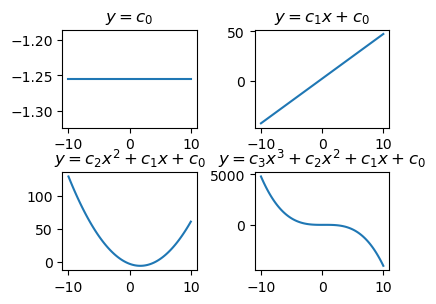

In [3]:
fig, axes = plt.subplots(2, 2)
fig.tight_layout()
titles = ["$y=c_0$",
          "$y=c_1x+c_0$",
          "$y=c_2x^2+c_1x+c_0$",
          "$y=c_3x^3+c_2x^2+c_1x+c_0$"
         ]

xs = np.linspace(-10, 10, 100)
for power, (ax, title) in enumerate(zip(axes.flat, titles), 1):
    coeffs = np.random.uniform(-5, 5, power)
    poly = np.poly1d(coeffs)
    ax.plot(xs, poly(xs))
    ax.set_title(title)

# plot a parabola using `dot` product


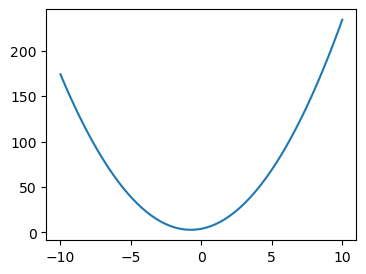

In [4]:
plt.Figure((2, 1.5))
xs = np.linspace(-10, 10, 101)
coeffs = np.array([2, 3, 4])
ys = np.dot(coeffs, [xs**2, xs**1, xs**0])
# nice parabola via a dot product
plt.plot(xs, ys);

## numpy versus 'all maths'

In [5]:
oned_vec = np.arange(5)
print(oned_vec, "-->", oned_vec * oned_vec)
print("self dot:", np.dot(oned_vec, oned_vec))

[0 1 2 3 4] --> [ 0  1  4  9 16]
self dot: 30


### row and column vectors

In [7]:
row_vec = np.arange(5).reshape(1, 5)
col_vec = np.arange(0, 50, 10).reshape(5, 1)
print("row vec:", row_vec, "col_vec:", col_vec, "dot:", np.dot(row_vec, col_vec), sep='\n')

row vec:
[[0 1 2 3 4]]
col_vec:
[[ 0]
 [10]
 [20]
 [30]
 [40]]
dot:
[[300]]


### swapping the order gives a different output

In [8]:
out = np.dot(col_vec, row_vec)
print(out)

[[  0   0   0   0   0]
 [  0  10  20  30  40]
 [  0  20  40  60  80]
 [  0  30  60  90 120]
 [  0  40  80 120 160]]


 this is the actuall definition of what `np.dot` does

### 1D and 2D aarays

In [9]:
col_vec = np.arange(0, 50, 10).reshape(5, 1)
row_vec = np.arange(0, 5).reshape(1, 5)
oned_vec = np.arange(5)
np.dot(oned_vec, col_vec)

array([300])

In [11]:
try:
    np.dot(col_vec, oned_vec) # *boom*
except ValueError as e:
    print("I went boom:", e)

I went boom: shapes (5,1) and (5,) not aligned: 1 (dim 1) != 5 (dim 0)


In [13]:
print(oned_vec.shape, col_vec.shape, sep="\n")

(5,)
(5, 1)


In [18]:
print(np.allclose(np.dot(oned_vec.reshape(1, 5), col_vec),
np.dot(oned_vec, col_vec)),
np.allclose(np.dot(row_vec, oned_vec.reshape(5, 1)),
np.dot(row_vec, oned_vec)))

True True


In [19]:
D = np.array([[1, 3],
[2, 5],
[2, 7],
[3, 2]])
w = np.array([1.5, 2.5])

In [20]:
np.dot(D,w)

array([ 9. , 15.5, 20.5,  9.5])

In [21]:
try:
    np.dot(w,D)
except ValueError:
    print("BOOM. :sadface:")

BOOM. :sadface:
